In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from utils import *

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
def solver_name_to_precision(name):
    asm_prec = name.split(".")[1].split(",")[0]
    if "Inv(torch." not in name:
        return asm_prec
    else:
        inv_prec = name.split("Inv(torch.")[1].split(")")[0]
        return f"{asm_prec}+{inv_prec}"

def solver_name_to_preconditioner(name):


In [ ]:
def generate_summary(df: pd.DataFrame):
    if "solve times" not in df.columns:
        return pd.DataFrame()

    df = df.copy()
    metadata_df = df.apply(extract_row_metadata, axis=1)
    metadata_cols = metadata_df.columns.tolist()
    df = pd.concat([df, metadata_df], axis=1)

    df["precision"] = df["solver"].apply(solver_name_to_precision)
    pivot_table = df.pivot_table(
        index=["dim", "p", "fine m", "coarse m"],
        columns=["precision"],
        values=metadata_cols,
        aggfunc="min",
    )
    return pivot_table

In [4]:
df = pd.read_csv("../results/experiment_precisions.csv")
df = process_experiments_df(df)
summary = generate_summary(df)
summary

cg setup time                                   \
precision                   float32 float32+bfloat16 float32+float16   
dim p fine m coarse m                                                  
2D  1 S10    S10        6320.067871      6413.808594     5752.701172   
             S8         2619.360840      2489.443848     2389.468994   
             S9         3134.333496      3307.590332     3357.457031   
    3 S9     S7         2443.519043      2448.431885     2431.901611   
             S8         2940.295166      2794.745605     2755.113525   
             S9         3426.075439      3679.740967     3400.308594   

                                                                     \
precision                  float64 float64+bfloat16 float64+float16   
dim p fine m coarse m                                                 
2D  1 S10    S10       5891.059570      5564.819336     5853.989258   
             S8        2659.003418      2415.175781     2321.604248   
             S9        3010.464111      3208.672852     3136.125732   
    3 S9     S7        2442.449707      2614.135986     2351.563965   
             S8        2848.540039      2705.838623     2715.214844   
             S9        3585.604492      3849.431885     3529.319580   

                                          cg time                   \
precision             float64+float32     float32 float32+bfloat16   
dim p fine m coarse m                                                
2D  1 S10    S10          5973.372070  612.992432       625.920593   
             S8           2302.732910  235.748413       211.333282   
             S9           3222.334961  269.264801       275.059387   
    3 S9     S7           2414.573975  953.987549       772.811646   
             S8           2793.557861  555.443237       529.380615   
             S9           3538.534424  604.816650       610.431396   

                                       ... preconditioner setup time  \
precision             float32+float16  ...          float64+bfloat16   
dim p fine m coarse m                  ...                             
2D  1 S10    S10           612.115723  ...               7383.693359   
             S8            211.446045  ...               2899.518799   
             S9            265.360626  ...               4805.770508   
    3 S9     S7            767.467896  ...               2938.930420   
             S8            525.714844  ...               3048.319824   
             S9            604.858032  ...               4226.087402   

                                                      preconditioner time  \
precision             float64+float16 float64+float32             float32   
dim p fine m coarse m                                                       
2D  1 S10    S10          7544.535156     7566.356445            9.528326   
             S8           2983.637695     2855.389648            2.093123   
             S9           3855.888672     3825.594238            3.217965   
    3 S9     S7           2887.398682     3140.889404            2.710470   
             S8           3213.817871     3045.459229            1.854090   
             S9           4057.748535     4127.164062            3.139981   

                                                                   \
precision             float32+bfloat16 float32+float16    float64   
dim p fine m coarse m                                               
2D  1 S10    S10              9.510896        9.506406  10.678080   
             S8               1.743683        1.743187   2.956736   
             S9               3.128051        3.130502   3.787786   
    3 S9     S7               1.825949        1.832838   4.540480   
             S8               1.603987        1.603792   2.528467   
             S9               3.088563        3.089949   3.685411   

                                                                        
precision             float64+bfloat16 float64+float16 float64+f

In [5]:
precisions = summary.columns.levels[1].to_list()
ds = summary.index.levels[0].to_list()
ps = summary.index.levels[1].to_list()


def shorten_precision(prec):
    return "+".join(
        [("fp" if p.startswith("f") else "bf") + p[-2:] for p in prec.split("+")]
    )

[shorten_precision(prec) for prec in precisions]

['fp32',
 'fp32+bf16',
 'fp32+fp16',
 'fp64',
 'fp64+bf16',
 'fp64+fp16',
 'fp64+fp32']

## Sanity check

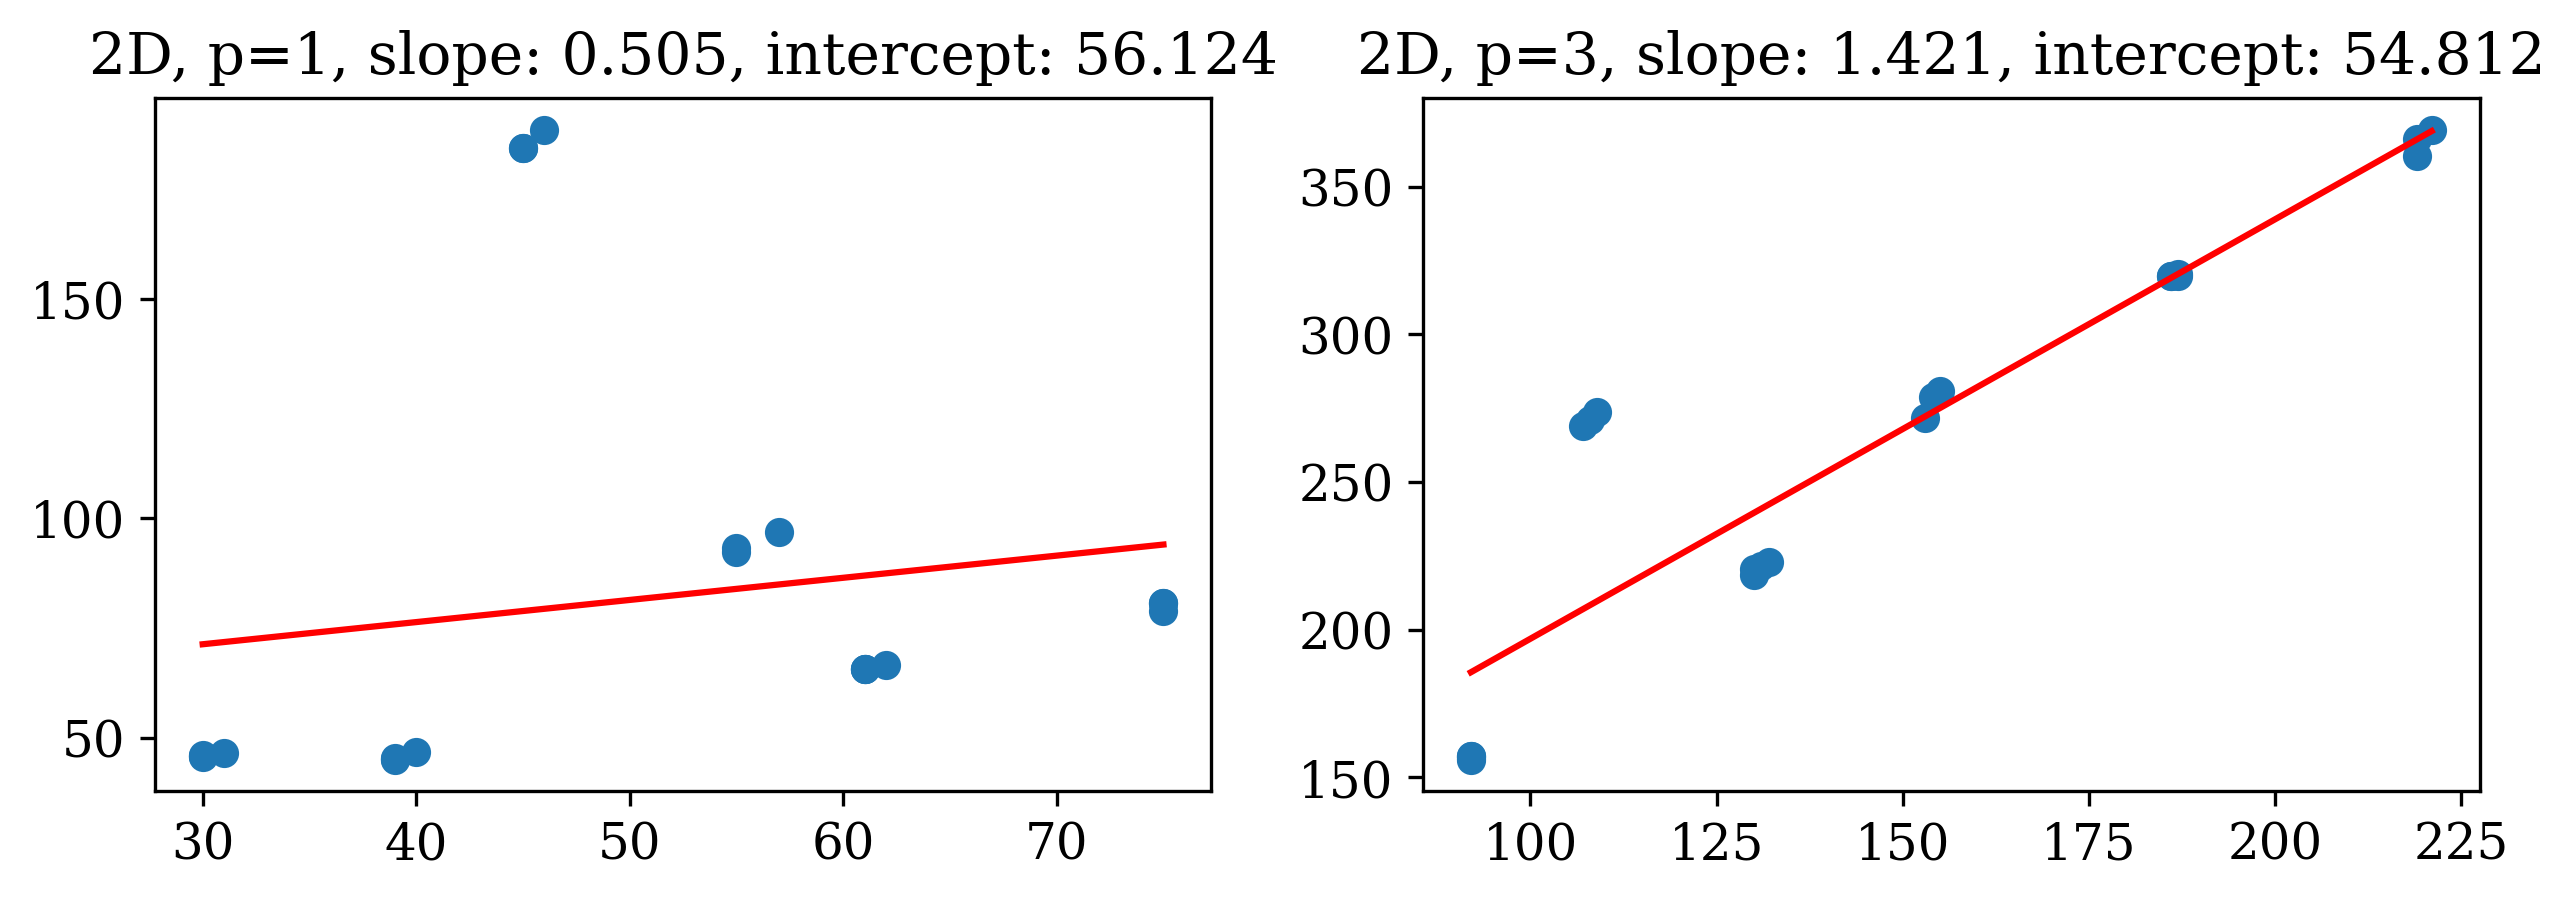

In [17]:
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(len(ds), len(ps), figsize=(5 * len(ps), 3 * len(ds)), dpi=300)
for i, d in enumerate(ds):
    for j, p in enumerate(ps):
        ax = axes[i * len(ps) + j]

        sp = summary.xs(d, level="dim").xs(p, level="p")
        iters = sp["iterations"].values.flatten()
        cg_time = (sp["cg time"] - sp["preconditioner time"] * sp["iterations"]).values.flatten()
        cg_time = cg_time[iters < 600]
        iters = iters[iters < 600]
        ax.scatter(iters, cg_time)

        model = LinearRegression().fit(iters.reshape(-1, 1), cg_time)
        ax.set_title(f"{d}, p={p}, slope: {model.coef_[0]:.3f}, intercept: {model.intercept_:.3f}")

        itx = np.linspace(iters.min(), iters.max(), 100).reshape(-1, 1)
        predicted = model.predict(itx)
        ax.plot(itx, predicted, color="red", label="Linear fit")

## Iteration count table

In [ ]:
nice_col_names = {
    "p": "$p$",
    "fine m": "$m$",
    "solvers m": "$M$",
    "coarse m": "$\\mathcal{M}$",
}

iter_summary = summary["iterations"][precisions].copy()
formatted_iter_table = iter_summary.astype(int).style.format_index(
    lambda prec: f"{{\\texttt{{{shorten_precision(prec)}}}}}",
    axis=1,
)
formatted_iter_table.index.rename(nice_col_names, inplace=True)
formatted_iter_table.columns.name = None


def highlight_values(s):
    return [""] + [
        "color: #ff0000;" if v > 500 else "color: #aaaaaa" if v == s.iloc[0] else ""
        for v in s[1:]
    ]


formatted_iter_table = formatted_iter_table.apply(highlight_values, axis=1)

formatted_iter_table

In [ ]:
iter_table_latex = formatted_iter_table.to_latex(
    hrules=True,
    multirow_align="t",
    column_format="rrr|" + 4 * "S[table-format=3, table-column-width=4.3em]",
    convert_css=True,
)
latex_lines = iter_table_latex.split("\n")
first_header_line = latex_lines.index("\\toprule") + 1
last_header_line = latex_lines.index("\\midrule") - 1
column_names = [None] * len(latex_lines[first_header_line].split("&"))
for line in latex_lines[first_header_line : last_header_line + 1]:
    line_col_names = [x.strip().removesuffix("\\\\") for x in line.split("&")]
    for i, col_name in enumerate(line_col_names):
        if col_name:
            column_names[i] = col_name
single_header_line = " & ".join(column_names) + " \\\\"
hacked_pivot_latex = "\n".join(
    latex_lines[:first_header_line]
    + [single_header_line]
    + latex_lines[last_header_line + 1 :]
)
with open("../docs/tables/experiment_precision_iterations.tex", "w") as f:
    f.write(hacked_pivot_latex)

## Plots

In [ ]:
def get_plot_df(p: int, prec: int):
    data = (
        summary.xs(p, level="p")
        .xs(prec, level="precision", axis=1)
        .reset_index()
        .set_index("coarse m")
    )
    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    # total_asm_rest = "$R_C$, $R_C^T$, type casts"
    total_asm_rest = "other ASM components"
    total_not_asm = "outer PCG"
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_asm_rest] = (
        data["asm time"] - data["local solvers time"] - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_asm] = (
        data["cg time"]
        - data[total_asm_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[[total_not_asm, total_asm_rest, total_coarse_solver, total_local_solvers]]
        / 1000
    )
    return to_plot

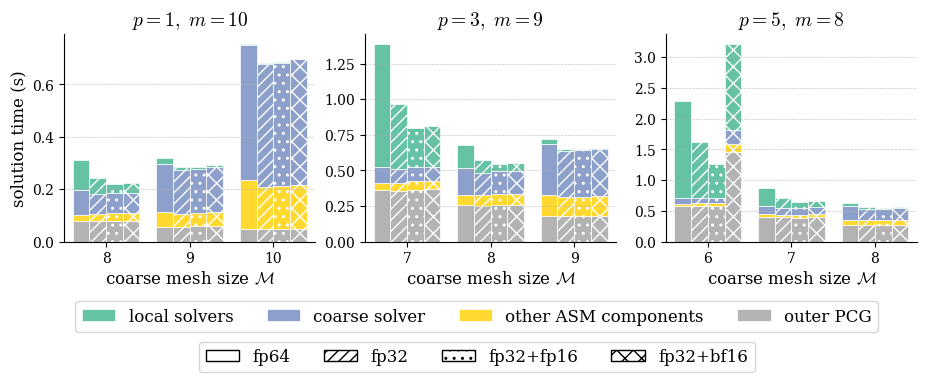

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.7))
# ['//', '\\\\', '--', 'xx', '..']
hatch_list = ["", "///", "..", "xx"]
for ax, p in zip(axes, ps):
    plot_clustered_stacked(
        ax,
        [get_plot_df(p, prec) for prec in precisions],
        precisions,
        hatch_list=hatch_list,
        add_legend=False,
    )
    m = summary.xs(p, level="p").index.get_level_values(0)[0]
    ax.set_title(f"$p={p},\\ m={m}$")
    ax.set_xlabel("coarse mesh size $\\mathcal{M}$")
    if p == 1:
        ax.set_ylabel("solution time (s)")
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.tick_params(axis="both", which="minor", labelsize=8)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncols=4,
)

proxies = []
for i, prec in enumerate(precisions):
    p = mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatch_list[i] or "",
        # alpha=alpha_list[i],
        label=prec,
    )
    proxies.append(p)
fig.legend(
    proxies,
    map(shorten_precision, precisions),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.23),
    ncols=4,
)
fig.savefig("../docs/thesis-media/precision_plots.svg", bbox_inches="tight")

## Bf16 convergence history

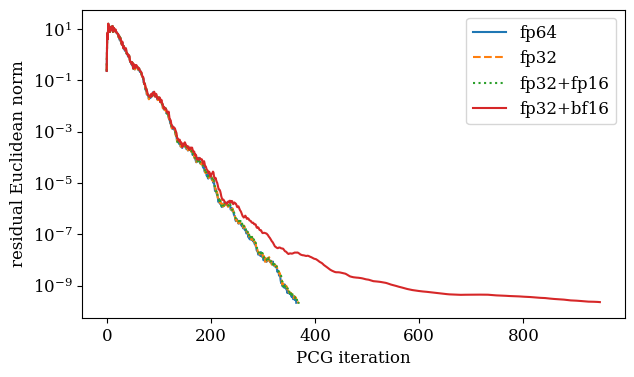

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

df_prec = df.apply(lambda row: solver_name_to_precision(row["solver"]), axis=1)
line_styles = ["-", "--", ":", "-"]
for i, prec in enumerate(precisions):
    res_norms = ast.literal_eval(
        df[
            (df["p"] == 5)
            & (df["coarse m"] == 6)
            & (df["solver"].str.contains("CG"))
            & (df_prec == prec)
        ].iloc[0]["metadata"]
    )["residual norms"]
    ax.plot(res_norms, label=shorten_precision(prec), linestyle=line_styles[i])

ax.set_yscale("log")
ax.legend(loc="upper right")
ax.set_xlabel("PCG iteration")
ax.set_ylabel("residual Euclidean norm")
fig.savefig("../docs/thesis-media/precision_residuals.svg", bbox_inches="tight")

## Numbers

In [ ]:
def get_speedup(what: str, prec: str, base="float64"):
    return summary[(what, base)] / summary[(what, prec)]

In [ ]:
get_speedup("cg time", "float32+float16", base="float32")

p  fine m  coarse m
1  10      8           1.097865
           9           1.010775
           10          0.998837
3  9       7           1.207015
           8           1.047074
           9           0.999175
5  8       6           1.279191
           7           1.101839
           8           1.018533
dtype: float64